In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [3]:
path = "../data/raw/insurance.csv"

df = pd.read_csv(path)

print(f"DataSet Shape: (rows, columns): {df.shape}")

df.head()



DataSet Shape: (rows, columns): (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
df.describe(include=['str'])
# df.value_counts()

,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


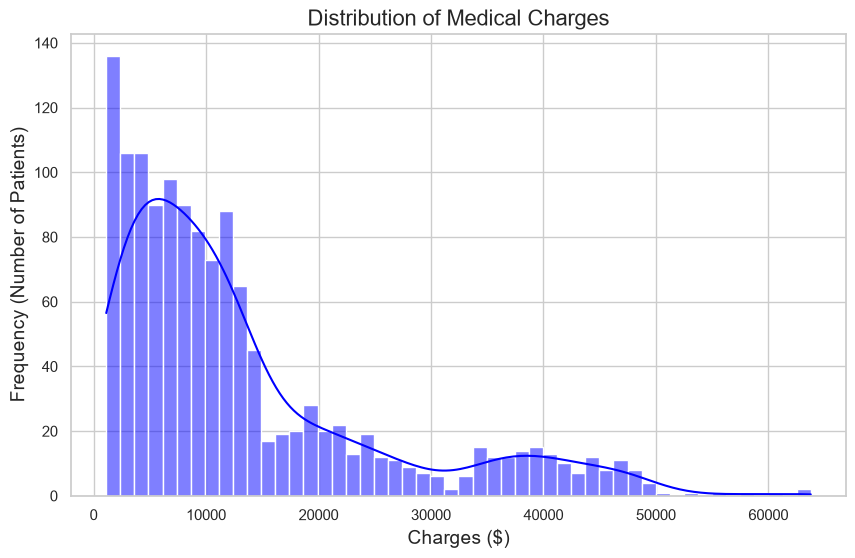

In [7]:
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10, 6))

sns.histplot(x = df['charges'], kde=True, bins=50, color='blue')

plt.title("Distribution of Medical Charges", fontsize=16)
plt.xlabel('Charges ($)', fontsize=14)
plt.ylabel('Frequency (Number of Patients)', fontsize=14)

plt.show()

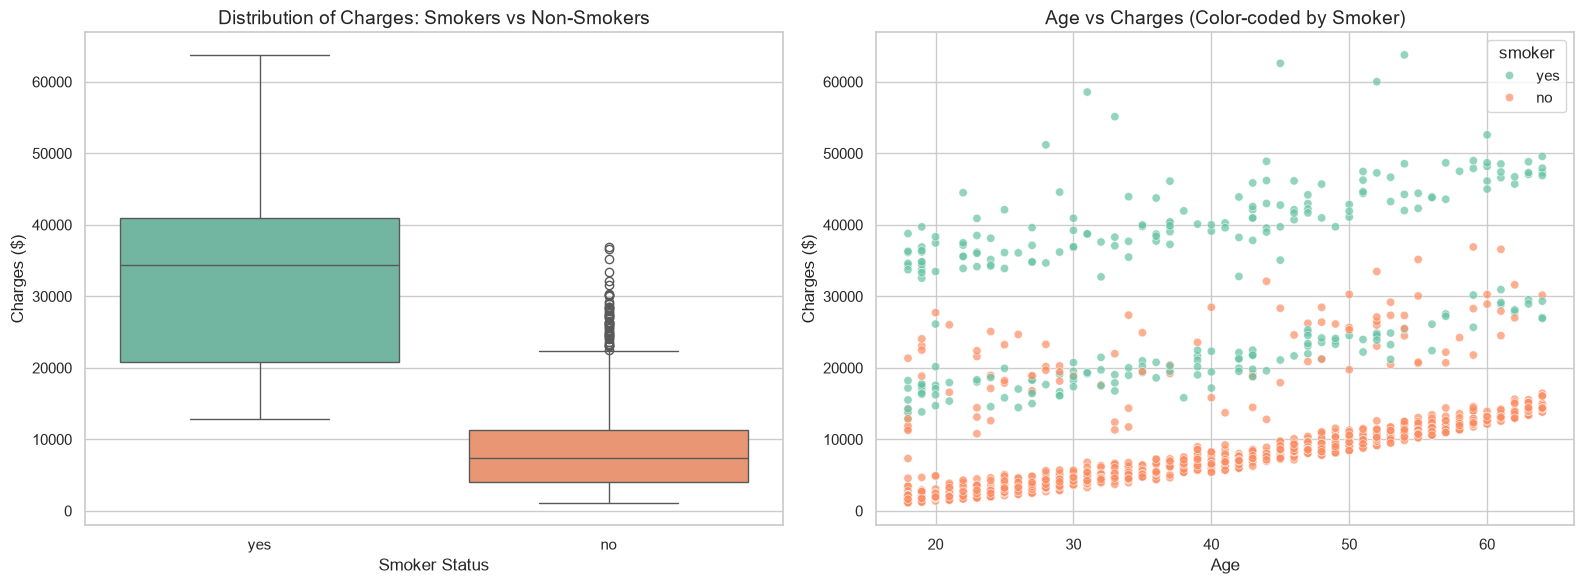

In [8]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

sns.boxplot(x='smoker', y='charges', hue = 'smoker',data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Distribution of Charges: Smokers vs Non-Smokers', fontsize=14)
axes[0].set_xlabel('Smoker Status')
axes[0].set_ylabel('Charges ($)')

sns.scatterplot(x='age', y = 'charges', hue = 'smoker', data = df, ax = axes[1], palette='Set2', alpha = 0.7)
axes[1].set_title('Age vs Charges (Color-coded by Smoker)', fontsize=14)
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Charges ($)')

plt.tight_layout()
plt.show()

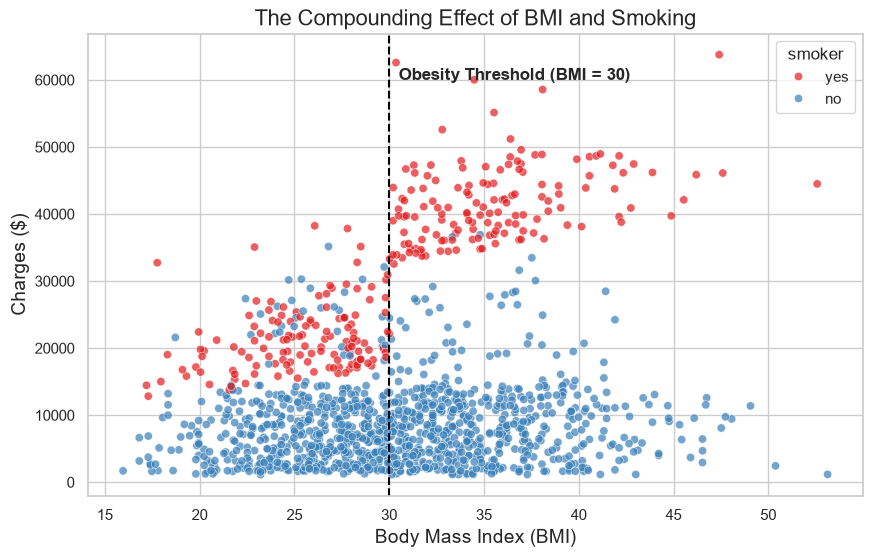

In [9]:
plt.figure(figsize = (10, 6))

sns.scatterplot(x = 'bmi', y = 'charges', hue = 'smoker', data=df, palette='Set1', alpha = 0.7)

plt.axvline(x=30, color = 'black', linestyle = '--', linewidth = 1.5)
plt.text(30.5, 60000, 'Obesity Threshold (BMI = 30)', fontsize = 12, fontweight = 'bold')

plt.title('The Compounding Effect of BMI and Smoking', fontsize=16)
plt.xlabel('Body Mass Index (BMI)', fontsize=14)
plt.ylabel('Charges ($)', fontsize=14)

plt.show()

In [10]:
df['sex'] = df['sex'].map({'female': 0, 'male': 1})

df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})

df = pd.get_dummies(df, columns = ['region'], drop_first = True)

df = df.astype(float)

df.head


<bound method NDFrame.head of        age  sex     bmi  children  smoker      charges  region_northwest  \
0     19.0  0.0  27.900       0.0     1.0  16884.92400               0.0   
1     18.0  1.0  33.770       1.0     0.0   1725.55230               0.0   
2     28.0  1.0  33.000       3.0     0.0   4449.46200               0.0   
3     33.0  1.0  22.705       0.0     0.0  21984.47061               1.0   
4     32.0  1.0  28.880       0.0     0.0   3866.85520               1.0   
...    ...  ...     ...       ...     ...          ...               ...   
1333  50.0  1.0  30.970       3.0     0.0  10600.54830               1.0   
1334  18.0  0.0  31.920       0.0     0.0   2205.98080               0.0   
1335  18.0  0.0  36.850       0.0     0.0   1629.83350               0.0   
1336  21.0  0.0  25.800       0.0     0.0   2007.94500               0.0   
1337  61.0  0.0  29.070       0.0     1.0  29141.36030               1.0   

      region_southeast  region_southwest  
0             

In [11]:
# y is the single column we want to predict
y = df['charges'] #output values

# Matrix of Inputs
X = df.drop('charges', axis = 1)   # Dropping the output label

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(f"X_train shape: {X_train.shape} (80% of rows for training)")
print(f"X_test shape:  {X_test.shape}  (20% of rows for testing)")

X_train shape: (1070, 8) (80% of rows for training)
X_test shape:  (268, 8)  (20% of rows for testing)


In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(X_train, y_train)

print(f"Base Intercept (b): ${model.intercept_:.2f}\n")


Base Intercept (b): $-11931.22



In [15]:
print("Feature Weights (w):")
for feature, weight in zip(X.columns, model.coef_):
    print(f"{feature.ljust(18)}: ${weight:,.2f}")

Feature Weights (w):
age               : $256.98
sex               : $-18.59
bmi               : $337.09
children          : $425.28
smoker            : $23,651.13
region_northwest  : $-370.68
region_southeast  : $-657.86
region_southwest  : $-809.80
